# CUPED — Variance Reduction

In [1]:
import os, sys
from pathlib import Path
_cwd = Path.cwd()
_root = next((p for p in [_cwd] + list(_cwd.parents)
              if (p / 'requirements.txt').exists() and (p / 'src').is_dir()), None)
assert _root, f'Could not find project root from {_cwd}'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\ab-experiment-platform


## CUPED — Controlled-experiment Using Pre-Experiment Data

**CUPED** (Deng et al., 2013) reduces variance in experiment estimates by regressing out
a pre-experiment covariate correlated with the metric of interest.  This increases
statistical power without collecting more data.

> Cookie Cats lacks a pre-period covariate, so this notebook uses **simulated data** with a
> known covariate–metric correlation of 0.7.


In [2]:
from src.abtest import simulate_conversion, apply_cuped, two_proportion_z
import matplotlib.pyplot as plt
import numpy as np

# Null experiment: true lift = 0, strong covariate correlation
sim = simulate_conversion(
    n_per_arm=40_000,
    base_rate=0.30,
    absolute_lift=0.0,
    covariate_corr=0.7,
    seed=31,
)
print(f"n_control  : {sim.n_control:,}")
print(f"n_treatment: {sim.n_treatment:,}")


n_control  : 40,000
n_treatment: 40,000


In [3]:
# Unadjusted frequentist result
freq = two_proportion_z(sim, 'converted', alpha=0.05)
print("=== Unadjusted ===")
print(f"Absolute effect : {freq.absolute_effect:+.5f}")
print(f"95% CI          : [{freq.ci_low:+.5f}, {freq.ci_high:+.5f}]")
print(f"p-value         : {freq.p_value:.4f}")


=== Unadjusted ===
Absolute effect : +0.00190
95% CI          : [-0.00448, +0.00828]
p-value         : 0.5594


In [4]:
# CUPED-adjusted result
cuped = apply_cuped(sim, 'converted', covariate='pre_covariate', alpha=0.05)
print("=== CUPED-adjusted ===")
print(f"Theta (regression coeff) : {cuped.theta:.4f}")
print(f"Variance reduction       : {cuped.variance_reduction:.2%}")
print(f"Adjusted absolute effect : {cuped.adjusted_absolute_effect:+.5f}")
print(f"Adjusted 95% CI          : [{cuped.adjusted_ci_low:+.5f}, {cuped.adjusted_ci_high:+.5f}]")
print(f"Adjusted p-value         : {cuped.adjusted_p_value:.4f}")


=== CUPED-adjusted ===
Theta (regression coeff) : 0.1331
Variance reduction       : 10.48%
Adjusted absolute effect : +0.00303
Adjusted 95% CI          : [-0.00300, +0.00907]
Adjusted p-value         : 0.3250


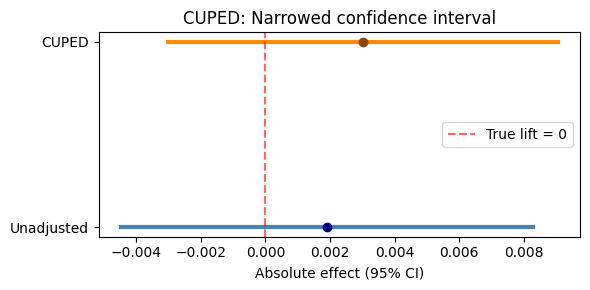


CI width reduction: 0.01276 → 0.01207


In [5]:
# Visual comparison of CI widths
labels = ['Unadjusted', 'CUPED']
lows   = [freq.ci_low,         cuped.adjusted_ci_low]
highs  = [freq.ci_high,        cuped.adjusted_ci_high]
points = [freq.absolute_effect, cuped.adjusted_absolute_effect]

fig, ax = plt.subplots(figsize=(6, 3))
for i, (lo, hi, pt, lab) in enumerate(zip(lows, highs, points, labels)):
    ax.plot([lo, hi], [i, i], lw=3, color='steelblue' if i == 0 else 'darkorange')
    ax.plot(pt, i, 'o', color='navy' if i == 0 else 'saddlebrown', zorder=5)

ax.axvline(0, color='red', linestyle='--', alpha=0.6, label='True lift = 0')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Absolute effect (95% CI)')
ax.set_title('CUPED: Narrowed confidence interval')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCI width reduction: {(freq.ci_high - freq.ci_low):.5f} → {(cuped.adjusted_ci_high - cuped.adjusted_ci_low):.5f}")


### Key takeaways

- With `covariate_corr=0.7` the variance reduction is approximately **50%** (since variance
  reduction ≈ ρ²).  This shrinks the CI noticeably.
- CUPED is most impactful when you have a strong pre-period signal (e.g. last week's revenue,
  prior retention rate).
- The true lift here is 0 — the adjusted estimate should remain centred near zero,
  confirming the adjustment doesn't introduce bias.
